# Pontifícia Universidade Católica de Minas Gerais
## Pós-Graduação em IA Generativa e Aplicações com LLMs
### Disciplina: Arquiteturas de Deep Learning

# Classificação de Imagens Territoriais com Redes Neurais Convolucionais (CNN)

> Nesta atividade, vamos treinar redes neurais convolucionais para classificar imagens territoriais em seis categorias: construções, floresta, geleira, montanha, mar e rua.

---

| Campo | Detalhe |
|:------|:--------|
| **Instituição** | Pontifícia Universidade Católica de Minas Gerais |
| **Programa** | Pós-Graduação em IA Generativa e Aplicações com LLMs |
| **Disciplina** | Arquiteturas de Deep Learning |
| **Professor** | Antônio dos Santos Ramos Neto |
| **Aluno** | Jair Pereira da Silva Junior |
| **Dataset** | Intel Image Classification |
| **Fonte** | [Kaggle - Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) |
| **Imagens de treino** | 14.034 imagens |
| **Imagens de teste** | 3.000 imagens |
| **Imagens para predição** | 7.301 imagens sem rótulo |
| **Classes** | `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street` |
| **Objetivo** | Construir e comparar uma CNN simples com uma CNN regularizada usando Batch Normalization e Dropout. |
| **Data de Entrega** | 08/06/2026, até 19:00 |

---

### Versão recomendada do Python

Use preferencialmente **Python 3.10 ou 3.11**. Essas versões costumam ser mais compatíveis com TensorFlow no Windows.

### Bibliotecas necessárias

| Biblioteca | Para que serve neste notebook |
|:-----------|:------------------------------|
| `tensorflow` | Criar, treinar e avaliar as redes neurais CNN |
| `numpy` | Trabalhar com arrays e cálculos numéricos |
| `pandas` | Organizar tabelas com contagens e resultados |
| `matplotlib` | Criar gráficos e exibir imagens |
| `seaborn` | Criar gráficos estatísticos, como a matriz de confusão |
| `scikit-learn` | Gerar relatório de classificação e matriz de confusão |
| `jupyter` | Abrir e executar este notebook |


In [2]:
# Opcional: execute esta célula somente se as bibliotecas ainda não estiverem instaladas.
# Em ambientes como Google Colab ou Jupyter local, talvez seja necessário reiniciar o kernel depois da instalação.

# !pip install tensorflow numpy pandas matplotlib seaborn scikit-learn jupyter

## 1. Entendendo o problema

Imagine que uma empresa recebe muitas fotos de diferentes lugares. Algumas fotos mostram prédios, outras mostram florestas, montanhas, mares, ruas ou geleiras.

O trabalho de uma CNN é parecido com o olhar humano: ela tenta encontrar padrões visuais nas imagens. Por exemplo:

- linhas retas e janelas podem indicar `buildings`;
- muitas árvores podem indicar `forest`;
- neve e gelo podem indicar `glacier`;
- relevo alto pode indicar `mountain`;
- água aberta pode indicar `sea`;
- asfalto e calçadas podem indicar `street`.

Nesta atividade, vamos comparar dois modelos:

1. **CNN simples:** aprende padrões das imagens, mas não usa técnicas extras para controlar overfitting.
2. **CNN regularizada:** usa Batch Normalization e Dropout para tentar generalizar melhor.

## 2. Importando as bibliotecas

As bibliotecas são ferramentas prontas. Em vez de criar tudo do zero, usamos pacotes especializados:

- `TensorFlow/Keras`: criação e treinamento das redes neurais;
- `Matplotlib` e `Seaborn`: gráficos;
- `Pandas` e `NumPy`: organização e cálculo com dados;
- `Pathlib`: manipulação de caminhos de arquivos.

In [3]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 3. Localizando as pastas do dataset

O dataset já está nesta pasta da atividade. Ele está dividido assim:

- `seg_train/seg_train`: imagens com rótulo para treinamento;
- `seg_test/seg_test`: imagens com rótulo para teste;
- `seg_pred/seg_pred`: imagens sem rótulo, usadas para simular predições novas.

Cada subpasta dentro de treino e teste representa uma classe.

In [4]:
BASE_DIR = Path.cwd()
TRAIN_DIR = BASE_DIR / 'seg_train' / 'seg_train'
TEST_DIR = BASE_DIR / 'seg_test' / 'seg_test'
PRED_DIR = BASE_DIR / 'seg_pred' / 'seg_pred'

for pasta in [TRAIN_DIR, TEST_DIR, PRED_DIR]:
    print(pasta, '-> existe?', pasta.exists())

c:\Users\junio\Downloads\puc_minas_2026\Arquiteturas de Deep Learning\Tarefa_2\seg_train\seg_train -> existe? True
c:\Users\junio\Downloads\puc_minas_2026\Arquiteturas de Deep Learning\Tarefa_2\seg_test\seg_test -> existe? True
c:\Users\junio\Downloads\puc_minas_2026\Arquiteturas de Deep Learning\Tarefa_2\seg_pred\seg_pred -> existe? True


## 4. Conferindo a quantidade de imagens por classe

Antes de treinar qualquer modelo, precisamos entender os dados.

Se uma classe tivesse muito mais imagens do que as outras, o modelo poderia ficar "viciado" nessa classe. Por isso, vamos contar quantas imagens existem em cada categoria.

In [5]:
def contar_imagens_por_classe(diretorio):
    dados = []
    for classe_dir in sorted(diretorio.iterdir()):
        if classe_dir.is_dir():
            quantidade = len(list(classe_dir.glob('*.jpg')))
            dados.append({'classe': classe_dir.name, 'imagens': quantidade})
    return pd.DataFrame(dados)

contagem_treino = contar_imagens_por_classe(TRAIN_DIR)
contagem_teste = contar_imagens_por_classe(TEST_DIR)

display(contagem_treino)
display(contagem_teste)

print('Total de treino:', contagem_treino['imagens'].sum())
print('Total de teste:', contagem_teste['imagens'].sum())
print('Total de imagens para predição:', len(list(PRED_DIR.glob('*.jpg'))))

,classe,imagens
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


,classe,imagens
0,buildings,437
1,forest,474
2,glacier,553
3,mountain,525
4,sea,510
5,street,501


Total de treino: 14034
Total de teste: 3000
Total de imagens para predição: 7301


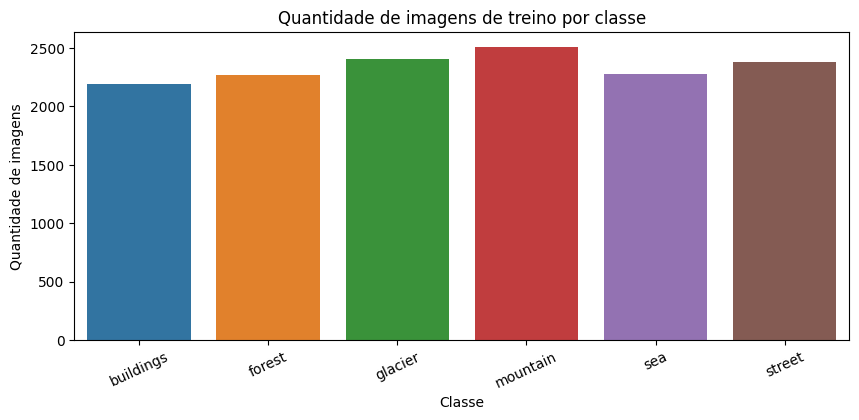

In [6]:
plt.figure(figsize=(10, 4))
sns.barplot(data=contagem_treino, x='classe', y='imagens')
plt.title('Quantidade de imagens de treino por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade de imagens')
plt.xticks(rotation=25)
plt.show()

## 5. Visualizando algumas imagens

Uma rede neural aprende olhando exemplos. Nós também devemos olhar alguns exemplos para entender o tipo de imagem que o modelo vai receber.

Nesta etapa, vamos mostrar uma imagem aleatória de cada classe.

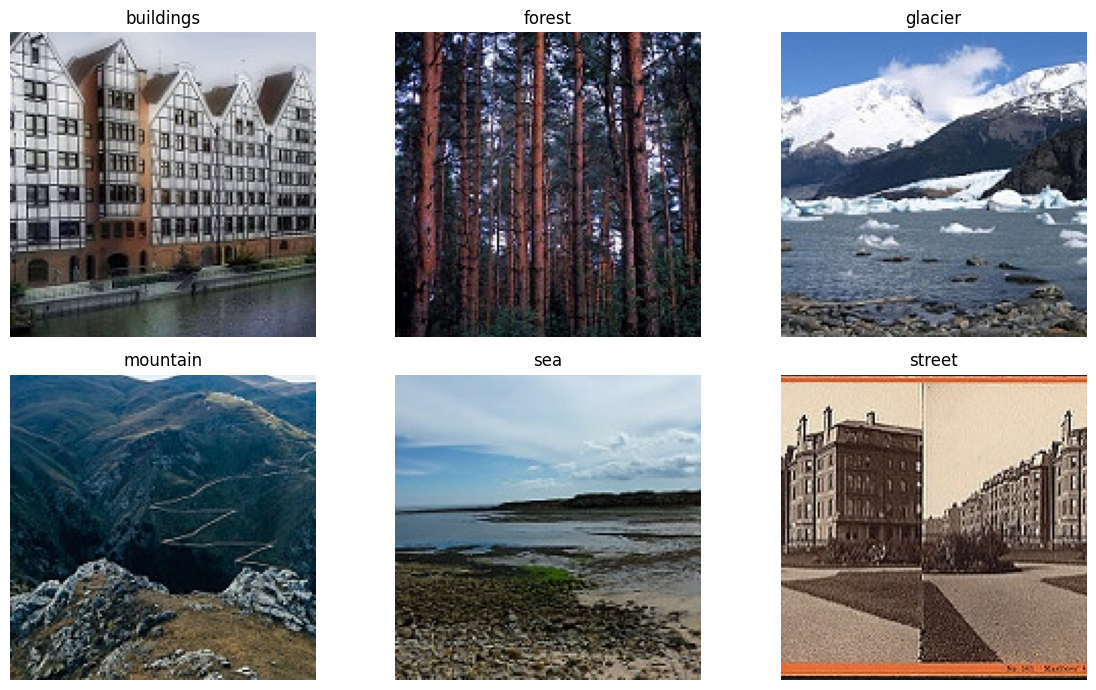

In [7]:
classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

plt.figure(figsize=(12, 7))
for i, nome_classe in enumerate(classes):
    imagens = list((TRAIN_DIR / nome_classe).glob('*.jpg'))
    imagem_escolhida = random.choice(imagens)
    img = tf.keras.utils.load_img(imagem_escolhida, target_size=(150, 150))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(nome_classe)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Preparando os dados para a CNN

Imagens podem ter tamanhos diferentes. Para a rede neural funcionar bem, vamos transformar todas para o mesmo tamanho: **150 x 150 pixels**.

Também vamos separar parte do treino para validação. Pense assim:

- **Treino:** o modelo estuda;
- **Validação:** usamos durante o treino para verificar se ele está aprendendo direito;
- **Teste:** usamos no final, como uma prova com imagens que o modelo não usou para aprender.

In [8]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Classes encontradas:', class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## 7. O que é uma CNN?

CNN significa **Convolutional Neural Network**, ou Rede Neural Convolucional.

Uma CNN aprende imagens em camadas:

1. As primeiras camadas percebem detalhes simples, como bordas e cores.
2. As camadas intermediárias percebem formas, texturas e partes de objetos.
3. As últimas camadas juntam tudo para decidir a classe da imagem.

As principais peças são:

- `Conv2D`: procura padrões visuais;
- `MaxPooling2D`: reduz o tamanho da imagem, guardando o que parece mais importante;
- `Flatten`: transforma a imagem processada em uma lista de números;
- `Dense`: toma a decisão final;
- `Softmax`: transforma a saída em probabilidades para cada classe.

## 8. Modelo 1: CNN simples

Este primeiro modelo é propositalmente simples. Ele será nosso ponto de comparação.

Ele tem camadas convolucionais, pooling e camadas densas, mas ainda não usa Batch Normalization nem Dropout.

In [10]:
def criar_cnn_simples(num_classes):
    modelo = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

cnn_simples = criar_cnn_simples(num_classes)
cnn_simples.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Treinando a CNN simples

Durante o treino, observe duas métricas:

- `accuracy`: porcentagem de acertos;
- `loss`: erro do modelo.

Um bom sinal é quando a acurácia de treino e validação sobem juntas. Se a acurácia de treino fica muito alta e a de validação fica para trás, isso pode indicar **overfitting**.

In [11]:
EPOCHS = 8

historico_simples = cnn_simples.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 207s 583ms/step - accuracy: 0.6316 - loss: 0.9489 - val_accuracy: 0.6793 - val_loss: 0.8158
Epoch 2/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 161s 458ms/step - accuracy: 0.7820 - loss: 0.5935 - val_accuracy: 0.7716 - val_loss: 0.6370
Epoch 3/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 449ms/step - accuracy: 0.8380 - loss: 0.4429 - val_accuracy: 0.7691 - val_loss: 0.6735
Epoch 4/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 144s 411ms/step - accuracy: 0.8925 - loss: 0.2998 - val_accuracy: 0.7947 - val_loss: 0.6941
Epoch 5/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 134s 382ms/step - accuracy: 0.9302 - loss: 0.1999 - val_accuracy: 0.8200 - val_loss: 0.7567
Epoch 6/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 404ms/step - accuracy: 0.9623 - loss: 0.1114 - val_accuracy: 0.8083 - val_loss: 0.9327
Epoch 7/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 423ms/step - accuracy: 0.9620 - loss: 0.1115 - val_accuracy: 0.8029 - val_loss: 0.9472
Epoch 8/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 151s 430ms/step - accuracy: 0.9743 - loss: 0

## 10. Modelo 2: CNN regularizada

Agora vamos criar uma CNN mais preparada para generalizar.

Ela usa duas técnicas importantes:

- **Batch Normalization:** ajuda a estabilizar o aprendizado, deixando os valores internos da rede mais organizados;
- **Dropout:** durante o treino, desliga aleatoriamente alguns neurônios. Isso força a rede a não depender demais de um único caminho.

Em linguagem simples: a CNN regularizada tenta aprender o padrão geral das imagens, não apenas decorar exemplos específicos.

In [12]:
def criar_cnn_regularizada(num_classes):
    modelo = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ])

    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

cnn_regularizada = criar_cnn_regularizada(num_classes)
cnn_regularizada.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,830,534 (18.43 MB)

 Trainable params: 4,829,830 (18.42 MB)

 Non-trainable params: 704 (2.75 KB)

## 11. Treinando a CNN regularizada

Vamos treinar pelo mesmo número de épocas para fazer uma comparação justa com a CNN simples.

In [13]:
historico_regularizada = cnn_regularizada.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 345s 969ms/step - accuracy: 0.6255 - loss: 1.0848 - val_accuracy: 0.2865 - val_loss: 3.0513
Epoch 2/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 318s 904ms/step - accuracy: 0.7213 - loss: 0.7696 - val_accuracy: 0.6725 - val_loss: 0.9044
Epoch 3/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 306s 869ms/step - accuracy: 0.7798 - loss: 0.6053 - val_accuracy: 0.6757 - val_loss: 0.8967
Epoch 4/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 313s 892ms/step - accuracy: 0.8115 - loss: 0.5316 - val_accuracy: 0.7908 - val_loss: 0.5724
Epoch 5/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 295s 841ms/step - accuracy: 0.8291 - loss: 0.4741 - val_accuracy: 0.7113 - val_loss: 0.8042
Epoch 6/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 291s 828ms/step - accuracy: 0.8498 - loss: 0.4235 - val_accuracy: 0.7017 - val_loss: 1.0064
Epoch 7/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 291s 829ms/step - accuracy: 0.8590 - loss: 0.3860 - val_accuracy: 0.8190 - val_loss: 0.4975
Epoch 8/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 292s 832ms/step - accuracy: 0.8791 - loss: 0

## 12. Comparando os gráficos de treino

Os gráficos ajudam a enxergar se o modelo está aprendendo bem.

Como interpretar:

- se treino e validação melhoram juntos, o aprendizado está saudável;
- se treino melhora muito e validação piora ou estaciona, pode ser overfitting;
- se os dois ficam ruins, pode ser underfitting.

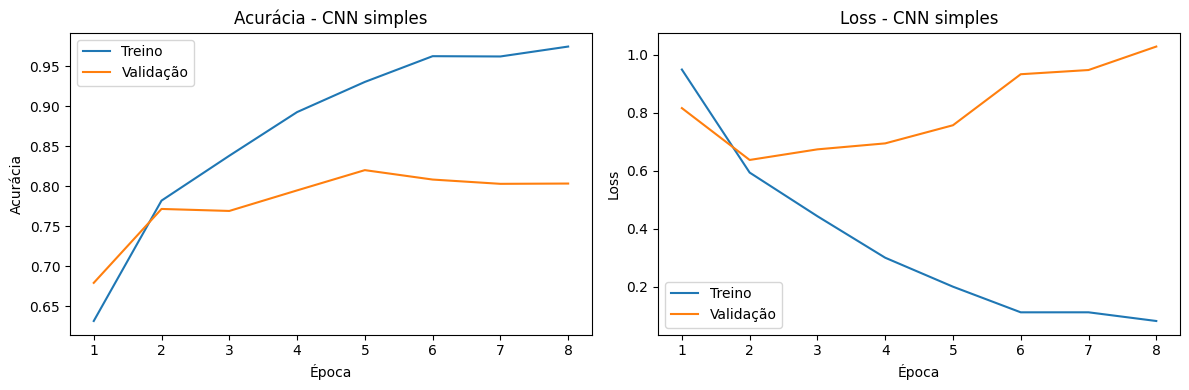

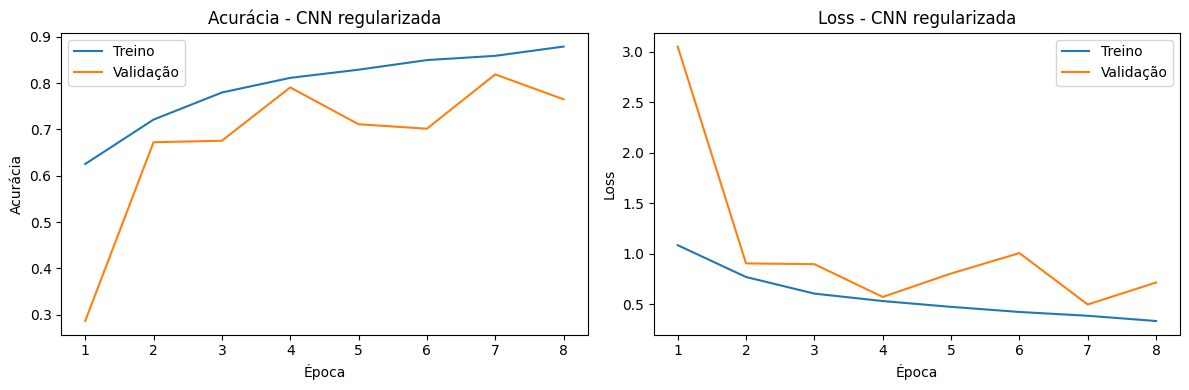

In [14]:
def plotar_historico(historico, titulo):
    acc = historico.history['accuracy']
    val_acc = historico.history['val_accuracy']
    loss = historico.history['loss']
    val_loss = historico.history['val_loss']
    epocas = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epocas, acc, label='Treino')
    plt.plot(epocas, val_acc, label='Validação')
    plt.title(f'Acurácia - {titulo}')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epocas, loss, label='Treino')
    plt.plot(epocas, val_loss, label='Validação')
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotar_historico(historico_simples, 'CNN simples')
plotar_historico(historico_regularizada, 'CNN regularizada')

## 13. Avaliando os modelos no conjunto de teste

Agora vem a parte mais importante: testar os modelos em imagens que eles não usaram durante o treino.

Isso mostra melhor se o modelo aprendeu de verdade ou apenas decorou os exemplos de treino.

In [15]:
resultado_simples = cnn_simples.evaluate(test_ds, verbose=0)
resultado_regularizada = cnn_regularizada.evaluate(test_ds, verbose=0)

comparacao = pd.DataFrame({
    'modelo': ['CNN simples', 'CNN regularizada'],
    'loss_teste': [resultado_simples[0], resultado_regularizada[0]],
    'acuracia_teste': [resultado_simples[1], resultado_regularizada[1]]
})

display(comparacao)

,modelo,loss_teste,acuracia_teste
0,CNN simples,1.051149,0.801333
1,CNN regularizada,0.773545,0.761000


## 14. Matriz de confusão

A matriz de confusão mostra onde o modelo acertou e onde errou.

Exemplo: se muitas imagens de `mountain` forem classificadas como `glacier`, isso pode indicar que o modelo confunde montanhas nevadas com geleiras.

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step
Relatório de classificação - CNN simples
              precision    recall  f1-score   support

   buildings       0.77      0.74      0.75       437
      forest       0.93      0.96      0.94       474
     glacier       0.77      0.72      0.74       553
    mountain       0.71      0.80      0.75       525
         sea       0.85      0.76      0.80       510
      street       0.81      0.84      0.82       501

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



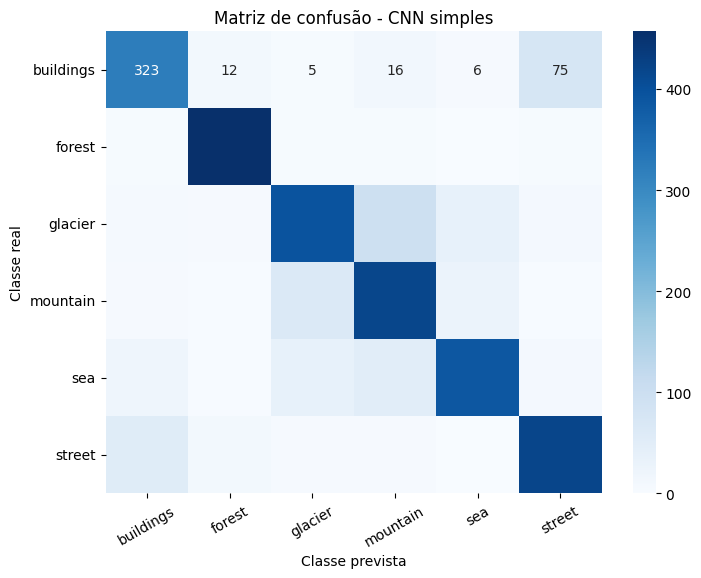

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step
Relatório de classificação - CNN regularizada
              precision    recall  f1-score   support

   buildings       0.66      0.87      0.75       437
      forest       0.99      0.69      0.81       474
     glacier       0.80      0.81      0.81       553
    mountain       0.90      0.49      0.64       525
         sea       0.68      0.90      0.77       510
      street       0.72      0.82      0.76       501

    accuracy                           0.76      3000
   macro avg       0.79      0.76      0.76      3000
weighted avg       0.79      0.76      0.76      3000



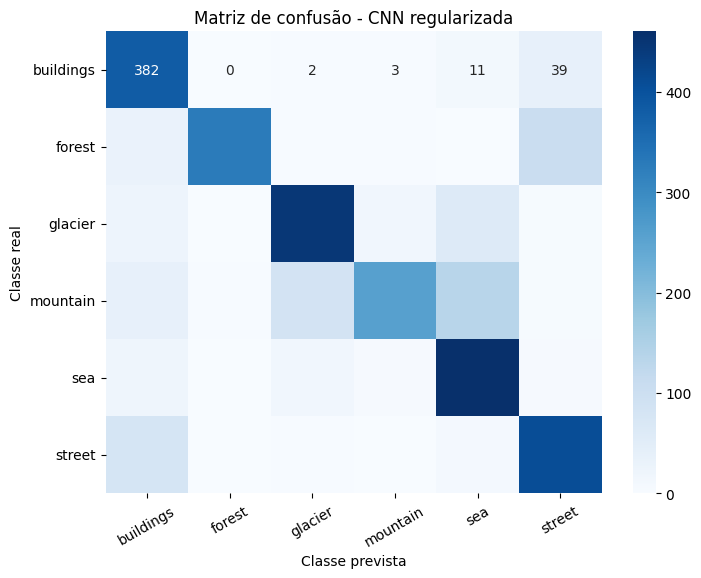

In [16]:
def avaliar_com_matriz_confusao(modelo, dataset, class_names, titulo):
    y_real = np.concatenate([y.numpy() for _, y in dataset])
    probabilidades = modelo.predict(dataset)
    y_pred = np.argmax(probabilidades, axis=1)

    print(f'Relatório de classificação - {titulo}')
    print(classification_report(y_real, y_pred, target_names=class_names))

    matriz = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusão - {titulo}')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe real')
    plt.xticks(rotation=30)
    plt.yticks(rotation=0)
    plt.show()

avaliar_com_matriz_confusao(cnn_simples, test_ds, class_names, 'CNN simples')
avaliar_com_matriz_confusao(cnn_regularizada, test_ds, class_names, 'CNN regularizada')

## 15. Fazendo predições em imagens novas

A pasta `seg_pred` possui imagens sem rótulo. Isso é parecido com uma situação real: chega uma imagem nova e queremos que o modelo diga qual é a classe mais provável.

Vamos usar o modelo regularizado, pois ele foi criado para ter melhor capacidade de generalização.

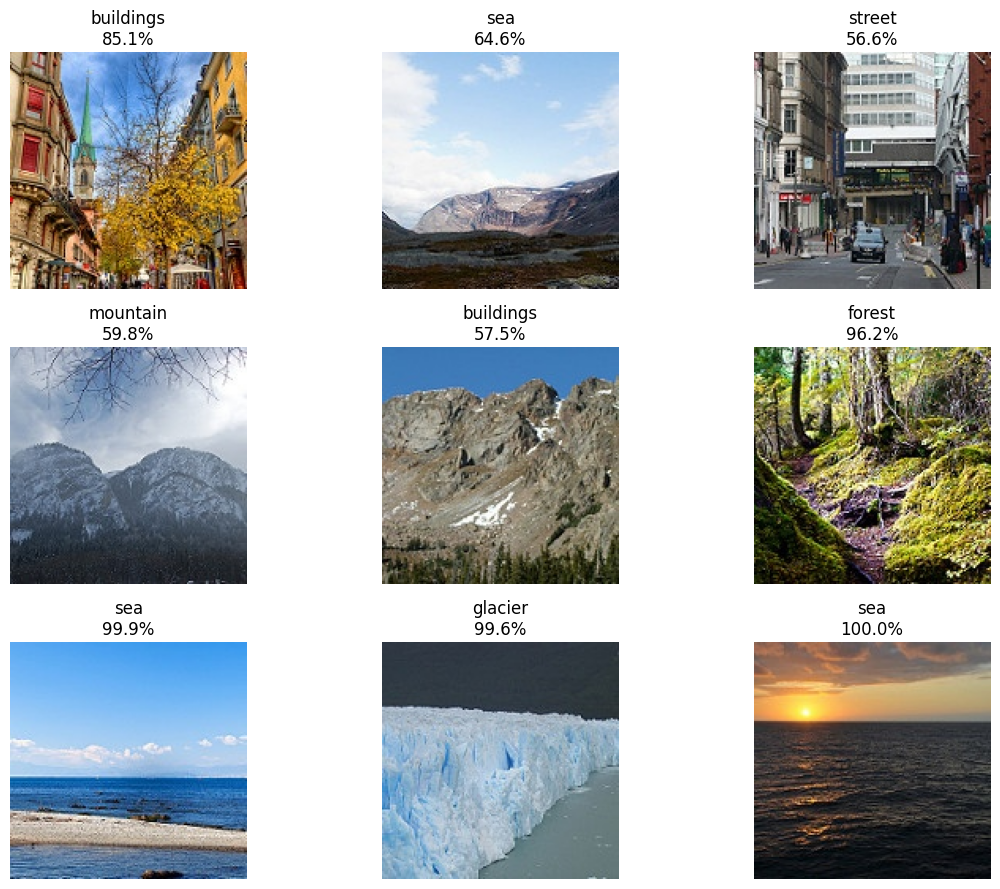

In [17]:
def prever_imagem(caminho_imagem, modelo, class_names):
    img = tf.keras.utils.load_img(caminho_imagem, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(img)
    array = tf.expand_dims(array, 0)

    probabilidades = modelo.predict(array, verbose=0)[0]
    indice = np.argmax(probabilidades)
    classe_prevista = class_names[indice]
    confianca = probabilidades[indice]

    return img, classe_prevista, confianca

imagens_predicao = sorted(list(PRED_DIR.glob('*.jpg')))[:9]

plt.figure(figsize=(12, 9))
for i, caminho in enumerate(imagens_predicao):
    img, classe, confianca = prever_imagem(caminho, cnn_regularizada, class_names)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f'{classe}\n{confianca:.1%}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 16. Análise final: overfitting e underfitting

Após executar os dois modelos, foi possível comparar o comportamento da CNN simples e da CNN regularizada. A tabela de avaliação no conjunto de teste apresentou os seguintes resultados:

| Modelo | Loss no teste | Acurácia no teste |
|:-------|--------------:|------------------:|
| CNN simples | 1,0511 | 80,13% |
| CNN regularizada | 0,7735 | 76,10% |

### CNN simples

A CNN simples apresentou a maior acurácia no conjunto de teste, chegando a **80,13%**. Isso significa que, a cada 100 imagens novas do teste, o modelo acertou aproximadamente 80.

Porém, observando o histórico de treinamento, a acurácia de treino chegou a **97,43%**, enquanto a acurácia de validação ficou em **80,33%** na última época. Essa diferença é grande e indica **overfitting**. Em outras palavras, o modelo aprendeu muito bem as imagens de treino, mas começou a ter mais dificuldade quando recebeu imagens que não conhecia.

Na matriz de confusão e no relatório de classificação, a classe com melhor desempenho foi `forest`, com F1-score de **0,94**. Já classes como `glacier`, `mountain` e `buildings` tiveram desempenho mais próximo, indicando que o modelo pode confundir paisagens visualmente parecidas, como montanhas e geleiras.

### CNN regularizada

A CNN regularizada usou **Batch Normalization** e **Dropout** para tentar reduzir o overfitting. No teste, ela alcançou **76,10%** de acurácia, ficando abaixo da CNN simples em quantidade de acertos.

Apesar disso, seu `loss` de teste foi menor: **0,7735**, contra **1,0511** da CNN simples. Isso mostra que a CNN regularizada produziu previsões menos penalizadas pela função de erro, mesmo tendo acertado menos classes no total.

O histórico de treinamento mostra que a CNN regularizada terminou com acurácia de treino de **87,91%** e validação de **76,51%**. A diferença entre treino e validação ainda existe, mas é menor do que na CNN simples. Isso confirma que a regularização ajudou a controlar parte do overfitting, embora não tenha sido suficiente para superar a acurácia final da CNN simples.

### Comparação geral

Pelo critério de **acurácia no teste**, a melhor escolha foi a **CNN simples**, pois obteve **80,13%** contra **76,10%** da CNN regularizada.

Mesmo assim, a CNN simples mostrou sinais claros de overfitting. Ela decorou melhor o conjunto de treino, mas perdeu desempenho quando avaliada em dados de validação e teste. A CNN regularizada foi mais conservadora: acertou menos no teste, mas teve menor erro (`loss`) e menor distância entre treino e validação.

Portanto, se o objetivo for apenas maximizar acertos nesta execução, a CNN simples é a vencedora. Se o objetivo for continuar melhorando o modelo para uso real, a CNN regularizada é um caminho promissor, mas precisaria de ajustes como mais épocas, aumento de dados, ajuste de taxa de aprendizado ou uso de transfer learning.

## 17. Conclusão

Nesta atividade, foram construídas e comparadas duas redes neurais convolucionais para classificar imagens territoriais do dataset Intel Image Classification em seis classes: `buildings`, `forest`, `glacier`, `mountain`, `sea` e `street`.

A **CNN simples** obteve o melhor resultado em acurácia de teste, com **80,13%**, mas apresentou sinais de **overfitting**, pois sua acurácia de treino ficou muito maior do que a acurácia de validação. Isso indica que o modelo aprendeu fortemente os exemplos de treino, mas não generalizou com a mesma força para imagens novas.

A **CNN regularizada**, com Batch Normalization e Dropout, teve acurácia de teste menor, com **76,10%**, mas apresentou menor `loss` no teste. Isso mostra que as técnicas de regularização ajudaram a controlar parte do erro, embora o modelo ainda precise de ajustes para superar a CNN simples.

De forma geral, o experimento mostrou que treinar uma CNN não é apenas buscar a maior acurácia de treino. É preciso observar também a validação, o teste, o `loss` e a matriz de confusão. Esses elementos ajudam a entender se a rede realmente aprendeu padrões visuais úteis ou se apenas memorizou exemplos.

Como melhoria futura, seria interessante testar **data augmentation**, aumentar o número de épocas com `EarlyStopping`, ajustar hiperparâmetros e comparar com modelos pré-treinados por **transfer learning**, como MobileNet, VGG16 ou ResNet.